# Notebook 08 — Validation / Baselines / Ablations (8×4 MLP)

Consolidated validation, baseline, and ablation experiments for the simplest BFT setting (SimpleMLP even/odd). Every section writes one publication-ready PDF to `figs/08_validation/` and the final cell dumps all numbers to a JSON.

**Compute profile:** set `NB08_MODE=cluster` (env var) for the full run; default `local` caps samples and NMF iterations for laptop iteration.

## §0 · Setup & config

In [1]:
import os, sys, json, copy, warnings

REPO = os.path.abspath('..')  # notebook lives in notebooks/
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
from scipy.stats import wilcoxon, ttest_rel
from sklearn.decomposition import MiniBatchNMF
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances, paired_cosine_distances
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from src import (
    SimpleMLP, load_experiment, save_experiment, get_transform,
    get_loaders_from_config, collect_layer_dicts, bft, evaluate,
    select_class_circuit, ablation_sweep, ablation_layer_sweep,
    extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree, compute_nmf_stability, compute_k_sensitivity,
    plot_pruning_by_layer_depth,
)
from src.bft import compute_joint_arbors_normalized
from src.training import train_epoch, label_transform_even_odd
from src.data_utils import get_mnist_loaders, label_transformed_loader
from src.robustness_utils import align_factors

RNG = np.random.default_rng(0)
DEVICE = torch.device('cpu')
FIG_DIR = os.path.join(REPO, 'figs', '08_validation')
RES_DIR = os.path.join(REPO, 'data', 'results')
MODEL_ROOT = os.path.join(REPO, 'data', 'models')
for d in (FIG_DIR, RES_DIR, MODEL_ROOT):
    os.makedirs(d, exist_ok=True)

EXP_BASE = 'mnist_even_odd_mlp_8_4_0134'
N_SEEDS, N_EPOCHS = 5, 30
N_BRANCHES = [1, 1, 2]
K_MAX_PER_LAYER = [5, 5, 5]
STIMULUS_THRESHOLD = 0.5
N_CLASSES = 2
CLASS_NAMES = {0: 'even', 1: 'odd'}
ABLATION_FRACS = [0.10, 0.20, 0.30]
DIGIT_FILTER = [0, 1, 3, 4]

# ── Compute profile ─────────────────────────────────────────────────────────────
# MODE='local'   : cheap — caps trace samples + low NMF iters, for laptop iteration.
# MODE='cluster' : full — all samples, high iters, all seeds (run on the cluster).
MODE = os.environ.get('NB08_MODE', 'local')
if MODE == 'cluster':
    N_TRACE = None          # use all correctly-classified samples
    BFT_MAX_ITER = 500      # NMF iters for the headline BFT trees
    AUX_MAX_ITER = 300      # NMF iters for per-seed auxiliary trees / stability fits
    STAB_SEEDS = 10         # NMF re-inits for stability
    NMF_SUB = 800           # row subsample for repeated stability/k fits
    SEED_SUBSET = range(N_SEEDS)
    IG_STEPS = 48
else:                       # 'local'
    N_TRACE = 600           # cap trace/analysis samples (keeps L1 arbor small)
    BFT_MAX_ITER = 120
    AUX_MAX_ITER = 80
    STAB_SEEDS = 4
    NMF_SUB = 300
    SEED_SUBSET = range(3)
    IG_STEPS = 12
print(f'MODE={MODE}  N_TRACE={N_TRACE}  BFT_MAX_ITER={BFT_MAX_ITER}  seeds={list(SEED_SUBSET)}')
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='Maximum number of iterations')

results = {}   # machine-readable results accumulator
figpaths = {}


def savefig(fig, name):
    p = os.path.join(FIG_DIR, name)
    fig.savefig(p, bbox_inches='tight')
    plt.show()
    figpaths[name] = os.path.relpath(p, REPO)
    print('  saved', figpaths[name])
    return p


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating, np.integer)):
        return float(o)
    if isinstance(o, (float, int, str, bool)) or o is None:
        return o
    return str(o)

MODE=local  N_TRACE=600  BFT_MAX_ITER=120  seeds=[0, 1, 2]


## §1 · Models — load or train 5 seeds

SimpleMLP 784→8→4→2 on MNIST digits {0,1,3,4}, relabeled even/odd. Trains 5 seeds (cached).

In [2]:
# ── §1 Models: load-or-train 5 seeds ───────────────────────────────────────────
print('\n§1 models')
BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [8, 4], 'output_dim': 2},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 32, 'digit_filter': DIGIT_FILTER},
    'label_transform': 'even_odd',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}
models_by_seed = {}
for seed in range(N_SEEDS):
    exp_dir = os.path.join(MODEL_ROOT, f'{EXP_BASE}_seed{seed}')
    if os.path.exists(os.path.join(exp_dir, 'weights.pt')):
        m, cfg = load_experiment(exp_dir, DEVICE)
        print(f'  seed {seed}: loaded')
    else:
        print(f'  seed {seed}: training...')
        torch.manual_seed(seed); np.random.seed(seed)
        m = SimpleMLP(**BASE_CONFIG['arch_kwargs']).to(DEVICE)
        cfg = dict(BASE_CONFIG, description=f'{EXP_BASE} seed {seed}')
        tr, te = get_mnist_loaders(batch_size=32, root='../data/', digit_filter=DIGIT_FILTER)
        opt = torch.optim.Adam(m.parameters(), lr=1e-3)
        crit = nn.CrossEntropyLoss()
        for _ in range(N_EPOCHS):
            train_epoch(m, tr, opt, crit, DEVICE, label_transform_even_odd)
        save_experiment(m, cfg, exp_dir)
    models_by_seed[seed] = (m, cfg)

model, config = models_by_seed[0]
train_loader, test_loader = get_loaders_from_config(config)
label_transform = get_transform(config['label_transform'])
_, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), DEVICE, label_transform)
print(f'  seed-0 test acc: {test_acc:.4f}')
results['setup'] = {'test_acc_seed0': test_acc, 'n_seeds': N_SEEDS,
                    'arch': [8, 4], 'digit_filter': DIGIT_FILTER}


§1 models
  seed 0: loaded
  seed 1: loaded
  seed 2: loaded
  seed 3: loaded
  seed 4: loaded


  seed-0 test acc: 0.9934


## §2 · Core BFT runs + layer data

Validated BFT tree (`validate=True`) + a richer `nnls_root` for fingerprints. In local mode the trace set is capped (`N_TRACE`).

In [3]:
# ── §2 Core BFT runs + layer data ──────────────────────────────────────────────
print('\n§2 BFT')
# Cap the samples used for tracing/analysis in local mode (cluster uses all).
if N_TRACE is not None:
    _idx = list(range(min(N_TRACE, len(test_loader.dataset))))
    trace_loader = DataLoader(Subset(test_loader.dataset, _idx), batch_size=256, shuffle=False)
else:
    trace_loader = test_loader
val_loader = label_transformed_loader(trace_loader, label_transform)
_collected = collect_layer_dicts(model, trace_loader, label_transform=label_transform, device=DEVICE)
all_images = _collected['images']
all_targets = _collected['targets']
all_digits = _collected['digits']
layer_inputs = [d['input_fmap'] for d in _collected['layer_data']]
n_samples = len(all_targets)
print(f'  n_samples={n_samples}, layer input dims={[x.shape[1] for x in layer_inputs]}')

tree_root = bft(model, val_loader, k_max=K_MAX_PER_LAYER, n_branches=N_BRANCHES,
                stimulus_threshold=STIMULUS_THRESHOLD, weighting='img_selectivity',
                validate=True, max_iter=BFT_MAX_ITER, verbose=1, n_jobs=3)
nnls_root = bft(model, val_loader, k_max=[10, 1, 2], n_branches=[8, 2, 2],
                stimulus_threshold=0, weighting='img_selectivity',
                max_iter=BFT_MAX_ITER, n_jobs=3)
assert tree_root.root.img_factors.shape[0] == n_samples, 'sample alignment mismatch'
print('  BFT ok; validation summary keys:', list((tree_root.validation_summary() or {}).keys()))


def sub_rows(X):
    if X.shape[0] <= NMF_SUB:
        return X
    return X[RNG.choice(X.shape[0], NMF_SUB, replace=False)]


def stab_mean(X, k):
    sim, _ = compute_nmf_stability(sub_rows(X), k, n_seeds=STAB_SEEDS, max_iter=AUX_MAX_ITER)
    off = sim[~np.eye(sim.shape[0], dtype=bool)]
    return sim, off


def arbor_pos(node):
    """Recompute the positive joint arbor NMF input for a node (as BFT built it)."""
    X = compute_joint_arbors_normalized(
        node.weight, layer_inputs[node.layer_idx],
        stimulus_weights=node.stimulus_weights,
        stimulus_threshold=node.stimulus_threshold)
    return np.clip(X, 0, None)


# one representative node per layer_idx (first on BFS order)
nodes_by_layer = {}
for nd in tree_root.nodes():
    nodes_by_layer.setdefault(nd.layer_idx, nd)
layer_ids = sorted(nodes_by_layer)


§2 BFT
  n_samples=596, layer input dims=[784, 8, 4]
[BFT] Layer 3/3 'layers.5' (fc)  path=[]
[BFT L3 'layers.5' (fc)]   K=2  t=0.031s
[BFT L3 'layers.5' (fc)]   recon: preact_R2=0.972  abs_CE_gap=0.0002  ratio_floored=0.024  (raw=2.961, n_eval=596)
[BFT] Layer 2/3 'layers.3' (fc)  path=[0]
[BFT L2 'layers.3' (fc)]   K=1  t=0.032s
[BFT L2 'layers.3' (fc)]   recon: preact_R2=0.991  abs_CE_gap=0.0002  ratio_floored=0.019  (raw=8.194, n_eval=100)
[BFT] Layer 1/3 'layers.1' (fc)  path=[0, 0]


[BFT L1 'layers.1' (fc)]   K=5  t=1.785s
[BFT L1 'layers.1' (fc)]   recon: preact_R2=0.932  abs_CE_gap=-0.0000  ratio_floored=0.002  (raw=0.962, n_eval=100)
[BFT] Layer 2/3 'layers.3' (fc)  path=[1]
[BFT L2 'layers.3' (fc)]   K=2  t=0.016s
[BFT L2 'layers.3' (fc)]   recon: preact_R2=0.994  abs_CE_gap=0.0000  ratio_floored=0.004  (raw=1.016, n_eval=100)
[BFT] Layer 1/3 'layers.1' (fc)  path=[1, 0]


[BFT L1 'layers.1' (fc)]   K=5  t=1.749s
[BFT L1 'layers.1' (fc)]   recon: preact_R2=0.680  abs_CE_gap=1.3570  ratio_floored=135.719  (raw=8688.562, n_eval=100)


  BFT ok; validation summary keys: ['overall', 'per_layer', 'individual']


## §2b · Algorithm output — the discovered circuits

The actual BFT result on this model: output-layer even/odd factors, per-class scaffold graphs, input-layer pixel receptive fields, and circuit sparsity (participation ratio). These are the main-paper circuit figures.


§2b circuit output


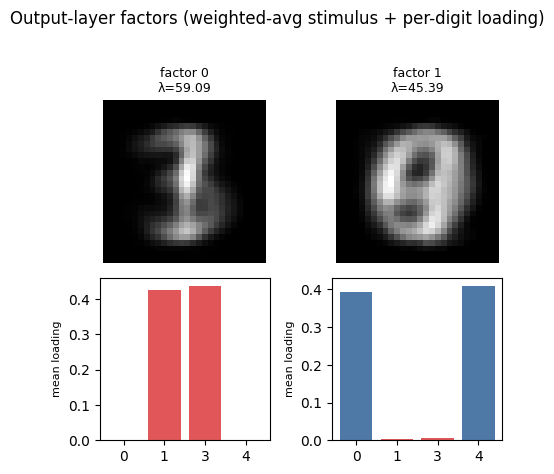

  saved figs/08_validation/fig_root_factors.pdf


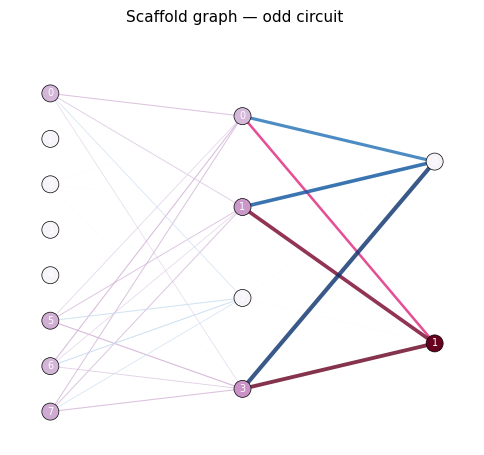

  saved figs/08_validation/fig_scaffold_odd.pdf


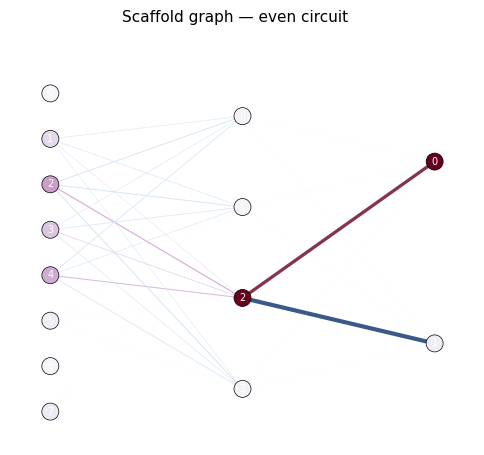

  saved figs/08_validation/fig_scaffold_even.pdf


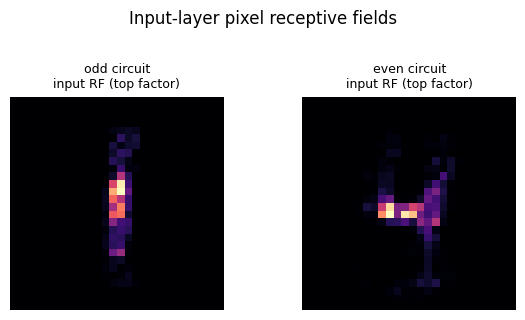

  saved figs/08_validation/fig_pixel_rfs.pdf
  circuit sparsity (participation ratio per transition): {'odd': {0: 3.002, 1: 1.018}, 'even': {0: 1.242, 1: 1.095}}


In [4]:
# ── §2b Core algorithm output: the discovered circuits (main-paper figures) ──────
print('\n§2b circuit output')
from src import (build_scaffold_edges, scaffold_loading_from_edges,
                 plot_scaffold_graph, plot_input_layer_factors)

LAYER_SIZES = [model.layers[li].out_features for li in model.linear_layer_indices()]
DIGIT_NAMES = {0: '0', 1: '1', 3: '3', 4: '4'}
flat_imgs = all_images.reshape(n_samples, -1)


def all_paths_of(root):
    if not root.children:
        return [[root]]
    return [[root] + p for ch in root.children for p in all_paths_of(ch)]


paths = all_paths_of(tree_root.root)                    # each: [root ... leaf]
class_of_path = {}                                       # path index -> even/odd class
for pi, pth in enumerate(paths):
    fk = pth[1].factor_idx                               # root factor this path follows
    top = np.argsort(tree_root.root.img_factors[:, fk])[::-1][:30]
    class_of_path[pi] = int(np.round(all_targets[top].mean()))

# (1) Root even/odd factors: weighted-average stimulus + per-digit loading
root = tree_root.root
Kr = root.img_factors.shape[1]
fig, ax = plt.subplots(2, Kr, figsize=(2.4 * Kr, 4.6))
ax = np.atleast_2d(ax)
for k in range(Kr):
    w = root.img_factors[:, k]
    wavg = (w[:, None] * flat_imgs).sum(0) / (w.sum() + 1e-9)
    ax[0, k].imshow(wavg.reshape(28, 28), cmap='gray'); ax[0, k].axis('off')
    ax[0, k].set_title(f'factor {k}\nλ={root.lambdas[k]:.2f}', fontsize=9)
    means = [w[all_digits == d].mean() for d in DIGIT_NAMES]
    ax[1, k].bar(range(len(DIGIT_NAMES)), means,
                 color=['#4e79a7' if d in (0, 4) else '#e15759' for d in DIGIT_NAMES])
    ax[1, k].set_xticks(range(len(DIGIT_NAMES)))
    ax[1, k].set_xticklabels(list(DIGIT_NAMES.values())); ax[1, k].set_ylabel('mean loading', fontsize=8)
fig.suptitle('Output-layer factors (weighted-avg stimulus + per-digit loading)', y=1.02)
fig.tight_layout()
savefig(fig, 'fig_root_factors.pdf')

def participation_ratio(x):
    """Threshold-free effective count: (Σ|x|)² / Σx². Low = concentrated/sparse."""
    x = np.abs(np.asarray(x, float))
    s2 = (x ** 2).sum()
    return float((x.sum() ** 2) / s2) if s2 > 0 else 0.0


# (2) Scaffold graphs, one per class circuit (+ per-layer sparsity from the drawn edges)
sparsity = {}
for pi, pth in enumerate(paths):
    layer_results = list(reversed(pth))                 # L1-first
    em, nem = build_scaffold_edges(layer_results[1:], fi='path',
                                   fi_seed=layer_results[0], top_pct=0.05)
    loading = scaffold_loading_from_edges(em)
    fig = plot_scaffold_graph(loading, em, LAYER_SIZES, neg_edge_matrices=nem)
    cls = CLASS_NAMES[class_of_path[pi]]
    fig.suptitle(f'Scaffold graph — {cls} circuit', fontsize=11)
    savefig(fig, f'fig_scaffold_{cls}.pdf')
    # sparsity = participation ratio of per-neuron edge strength at each transition
    per_layer = {t: {'participation_ratio': round(participation_ratio(np.abs(E).sum(1)), 3),
                     'total': int(E.shape[0])} for t, E in enumerate(em)}
    sparsity[cls] = {'participation_ratio_per_transition': per_layer}

# (3) Input-layer pixel receptive fields per class circuit (summed over hidden units)
leaves = [pth[-1] for pth in paths]
fig, ax = plt.subplots(1, len(leaves), figsize=(3 * len(leaves), 3))
ax = np.atleast_1d(ax)
for a, (pi, leaf) in zip(ax, enumerate(leaves)):
    n_out = leaf.weight.shape[0]
    rf = leaf.connection_factors[:, 0].reshape(n_out, 784).sum(0)
    a.imshow(rf.reshape(28, 28), cmap='magma'); a.axis('off')
    a.set_title(f'{CLASS_NAMES[class_of_path[pi]]} circuit\ninput RF (top factor)', fontsize=9)
fig.suptitle('Input-layer pixel receptive fields', y=1.05)
fig.tight_layout()
savefig(fig, 'fig_pixel_rfs.pdf')

# (4) Circuit sparsity — participation ratio of the drawn scaffold edges per class.
# Lower = sparser circuit; validates the paper's "odd circuit is sparser" claim.
results['circuits'] = {'sparsity': sparsity, 'layer_sizes': LAYER_SIZES}
print('  circuit sparsity (participation ratio per transition):',
      {c: {t: v['participation_ratio'] for t, v in s['participation_ratio_per_transition'].items()}
       for c, s in sparsity.items()})

## §3 · Validation — NMF factor stability + k-sensitivity

Reproducibility of the factors across random seeds (Hungarian-matched cosine) and sensitivity to the chosen rank K.


§3 NMF stability


  L0: k=5 stability=0.869±0.042
  L1: k=1 stability=1.000±0.000
  L2: k=2 stability=1.000±0.000


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_7009/2253467676.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([stab[li]['off_diag'] for li in layer_ids],


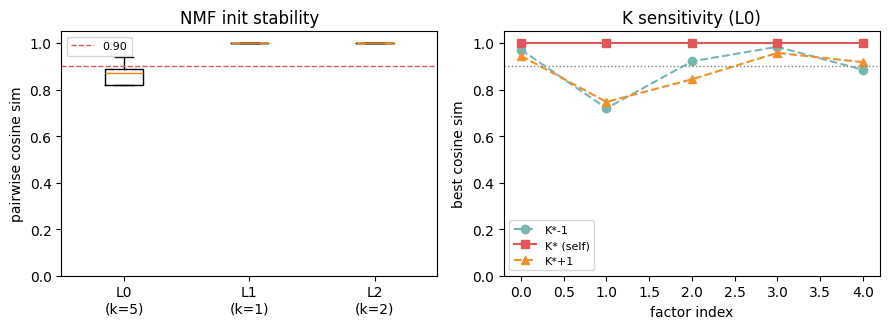

  saved figs/08_validation/fig_nmf_stability.pdf


'/Users/johannesbertram/repos/Weight_Interpretability/figs/08_validation/fig_nmf_stability.pdf'

In [5]:
# ── §3 NMF stability + k-sensitivity ────────────────────────────────────────────
print('\n§3 NMF stability')
stab = {}
for li in layer_ids:
    nd = nodes_by_layer[li]
    X = arbor_pos(nd)
    k = nd.img_factors.shape[1]
    sim, off = stab_mean(X, k)
    stab[li] = {'k': int(k), 'mean': float(off.mean()), 'std': float(off.std()),
                'off_diag': off.tolist()}
    print(f'  L{li}: k={k} stability={off.mean():.3f}±{off.std():.3f}')

# k-sensitivity on the input-side layer arbor
li0 = layer_ids[0]
nd0 = nodes_by_layer[li0]
ksens, _ = compute_k_sensitivity(sub_rows(arbor_pos(nd0)), nd0.img_factors.shape[1],
                                 n_seeds=3, max_iter=AUX_MAX_ITER)
ksens_json = {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in ksens.items()}
results['nmf_stability'] = {'per_layer': stab,
                            'k_sensitivity_L%d' % li0: ksens_json}

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].boxplot([stab[li]['off_diag'] for li in layer_ids],
              labels=[f'L{li}\n(k={stab[li]["k"]})' for li in layer_ids])
ax[0].axhline(0.9, ls='--', c='#e15759', lw=1, label='0.90')
ax[0].set(ylabel='pairwise cosine sim', title='NMF init stability', ylim=(0, 1.05))
ax[0].legend(fontsize=8)
kx = list(range(nd0.img_factors.shape[1]))
if ksens.get('k_minus1') is not None:
    ax[1].plot(kx, ksens['k_minus1'], 'o--', c='#76b7b2', label='K*-1')
ax[1].plot(kx, ksens['k_star'], 's-', c='#e15759', label='K* (self)')
ax[1].plot(kx, ksens['k_plus1'], '^--', c='#f28e2b', label='K*+1')
ax[1].axhline(0.9, ls=':', c='gray', lw=1)
ax[1].set(xlabel='factor index', ylabel='best cosine sim',
          title=f'K sensitivity (L{li0})', ylim=(0, 1.05))
ax[1].legend(fontsize=8)
fig.tight_layout()
savefig(fig, 'fig_nmf_stability.pdf')

## §4 · Validation — causal reconstruction fidelity

Robust metrics: pre-activation R² and absolute CE gap (headline) plus the floored ratio. The raw ratio blows up on confident samples; these separate genuine reconstruction failure from that artifact.


§4 recon validation


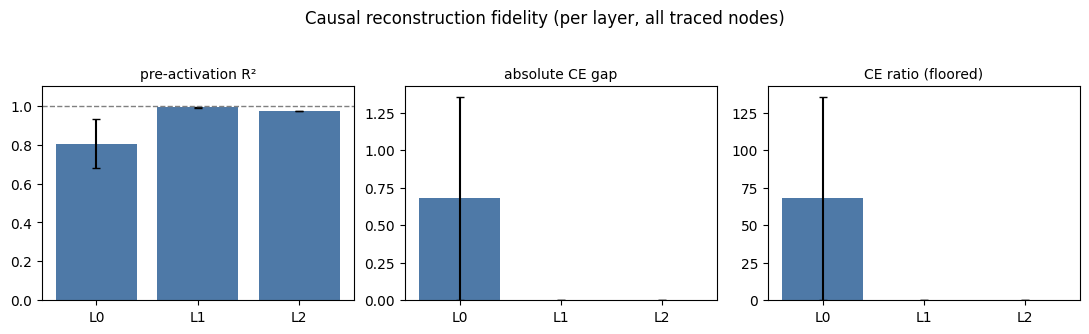

  saved figs/08_validation/fig_recon_validation.pdf
  overall preact_R2 median=0.972, worst node R2=0.680


In [6]:
# ── §4 Causal reconstruction validation (robust metrics) ─────────────────────────
print('\n§4 recon validation')
vsum = tree_root.validation_summary()
results['recon_validation'] = {
    'overall': jsonable(vsum['overall']),
    'per_layer': jsonable(vsum['per_layer']),
    'individual': jsonable(vsum['individual']),
}
METR = ['preact_r2', 'abs_ce_gap', 'loss_ratio_floored', 'loss_ratio_all']
lids = sorted(vsum['per_layer'])
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, m, ttl in zip(ax, ['preact_r2', 'abs_ce_gap', 'loss_ratio_floored'],
                     ['pre-activation R²', 'absolute CE gap', 'CE ratio (floored)']):
    means = [vsum['per_layer'][li][m]['mean'] for li in lids]
    stds = [vsum['per_layer'][li][m]['std'] for li in lids]
    a.bar([f'L{li}' for li in lids], means, yerr=stds, color='#4e79a7', capsize=3)
    a.set_title(ttl, fontsize=10)
    if m == 'preact_r2':
        a.axhline(1.0, ls='--', c='gray', lw=1); a.set_ylim(top=1.1)
fig.suptitle('Causal reconstruction fidelity (per layer, all traced nodes)', y=1.03)
fig.tight_layout()
savefig(fig, 'fig_recon_validation.pdf')
print('  overall preact_R2 median=%.3f, worst node R2=%.3f' % (
    vsum['overall']['preact_r2']['median'], vsum['overall']['preact_r2']['min']))

## §5 · Validation — NNLS projection round-trip

Project the training stimuli back onto the fixed factors and measure fingerprint cosine recovery.


§5 NNLS round-trip


  round-trip cosine: 0.9841±0.0195 (min 0.8947)


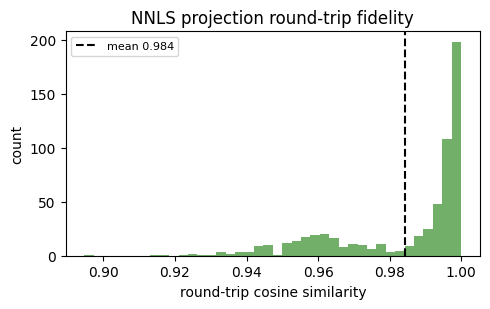

  saved figs/08_validation/fig_nnls_roundtrip.pdf


'/Users/johannesbertram/repos/Weight_Interpretability/figs/08_validation/fig_nnls_roundtrip.pdf'

In [7]:
# ── §5 NNLS round-trip fidelity ─────────────────────────────────────────────────
print('\n§5 NNLS round-trip')
proj_rt = project_stimuli_onto_tree(nnls_root, layer_inputs)
F_orig = extract_fingerprint_matrix(nnls_root, np.arange(n_samples))
F_rt = extract_fingerprint_matrix(proj_rt, np.arange(n_samples))
rt = 1.0 - paired_cosine_distances(F_orig, F_rt)
results['nnls_roundtrip'] = {'mean': float(rt.mean()), 'std': float(rt.std()),
                             'min': float(rt.min())}
print(f'  round-trip cosine: {rt.mean():.4f}±{rt.std():.4f} (min {rt.min():.4f})')
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.hist(rt, bins=40, color='#59a14f', alpha=0.85)
ax.axvline(rt.mean(), c='k', ls='--', label=f'mean {rt.mean():.3f}')
ax.set(xlabel='round-trip cosine similarity', ylabel='count',
       title='NNLS projection round-trip fidelity')
ax.legend(fontsize=8)
fig.tight_layout()
savefig(fig, 'fig_nnls_roundtrip.pdf')

## §6 · Validation — fingerprint separability (quantified)

Silhouette + kNN accuracy of BFT fingerprints vs raw hidden activations (turns the qualitative "MDS>PCA" claim into numbers).


§6 separability


  even/odd  BFT sil=0.630 knn=1.000 | act sil=0.802 knn=1.000
  4-digit   BFT sil=0.337 knn=0.971 | act sil=0.303 knn=0.946


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


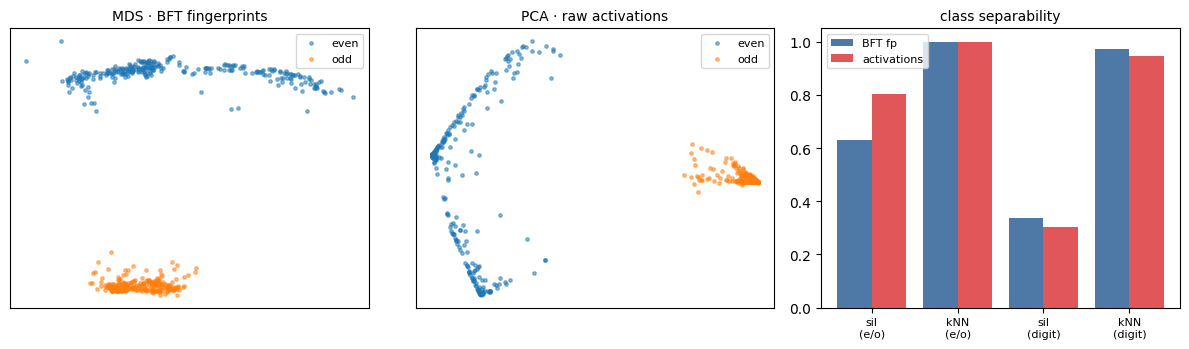

  saved figs/08_validation/fig_fingerprint_separability.pdf


In [8]:
# ── §6 Fingerprint separability, quantified ─────────────────────────────────────
print('\n§6 separability')
labels = all_targets.astype(int)
F_bft = extract_fingerprint_matrix(nnls_root, np.arange(n_samples))       # BFT fingerprints
A_act = np.concatenate([layer_inputs[1], layer_inputs[2]], axis=1)         # hidden activations


def sep_metrics(X, y):
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    sil = float(silhouette_score(Xn, y))
    knn = float(cross_val_score(KNeighborsClassifier(5), Xn, y, cv=5).mean())
    return sil, knn


sil_b, knn_b = sep_metrics(F_bft, labels)
sil_a, knn_a = sep_metrics(A_act, labels)
# Digit-level (4-class) separability — even/odd is trivially separable (kNN=1 for both),
# so the informative test is whether the fingerprint separates the 4 underlying DIGITS
# (0,1,3,4) better than activations — this directly probes the within-class sub-circuit claim.
dlab = all_digits.astype(int)
sil_bd, knn_bd = sep_metrics(F_bft, dlab)
sil_ad, knn_ad = sep_metrics(A_act, dlab)
results['separability'] = {
    'by_task_even_odd': {
        'bft_fingerprint': {'silhouette': sil_b, 'knn_acc': knn_b, 'dim': int(F_bft.shape[1])},
        'raw_activations': {'silhouette': sil_a, 'knn_acc': knn_a, 'dim': int(A_act.shape[1])},
    },
    'by_digit_4class': {
        'bft_fingerprint': {'silhouette': sil_bd, 'knn_acc': knn_bd},
        'raw_activations': {'silhouette': sil_ad, 'knn_acc': knn_ad},
    },
}
print(f'  even/odd  BFT sil={sil_b:.3f} knn={knn_b:.3f} | act sil={sil_a:.3f} knn={knn_a:.3f}')
print(f'  4-digit   BFT sil={sil_bd:.3f} knn={knn_bd:.3f} | act sil={sil_ad:.3f} knn={knn_ad:.3f}')

# MDS(BFT cosine) vs PCA(activations) visual + metric bars
emb_bft = MDS(n_components=2, dissimilarity='precomputed', random_state=0,
              normalized_stress='auto').fit_transform(cosine_distances(F_bft))
emb_act = PCA(2).fit_transform(A_act)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
for a, emb, ttl in [(ax[0], emb_bft, 'MDS · BFT fingerprints'),
                    (ax[1], emb_act, 'PCA · raw activations')]:
    for c in np.unique(labels):
        a.scatter(*emb[labels == c].T, s=6, alpha=0.5, label=CLASS_NAMES[c])
    a.set_title(ttl, fontsize=10); a.legend(fontsize=8); a.set_xticks([]); a.set_yticks([])
xb = np.arange(4)
ax[2].bar(xb - 0.2, [sil_b, knn_b, sil_bd, knn_bd], 0.4, label='BFT fp', color='#4e79a7')
ax[2].bar(xb + 0.2, [sil_a, knn_a, sil_ad, knn_ad], 0.4, label='activations', color='#e15759')
ax[2].set_xticks(xb)
ax[2].set_xticklabels(['sil\n(e/o)', 'kNN\n(e/o)', 'sil\n(digit)', 'kNN\n(digit)'], fontsize=8)
ax[2].set_title('class separability', fontsize=10); ax[2].legend(fontsize=8)
fig.tight_layout()
savefig(fig, 'fig_fingerprint_separability.pdf')


from src import per_class_accuracy
from src.ablation_utils import ablate_model, extract_importance_scores  # noqa

## §7 · Baseline + ablation — causal pruning across seeds

Target-vs-bystander accuracy drop across seeds and methods (bft_top/bottom, magnitude, act_magnitude, taylor, random) with Wilcoxon + paired t-test, plus a layer-depth sweep.


§7 ablation (multi-seed)


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_7009/3750028773.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mask = np.isin(np.array(mnist_test_full.targets), DIGIT_FILTER)


  seed 0 done


  seed 1 done


  seed 2 done
  bft_top target drop=0.827 bystander=0.161 Wilcoxon p=1.88e-01; bft_top vs random AUC t-test p=7.58e-04


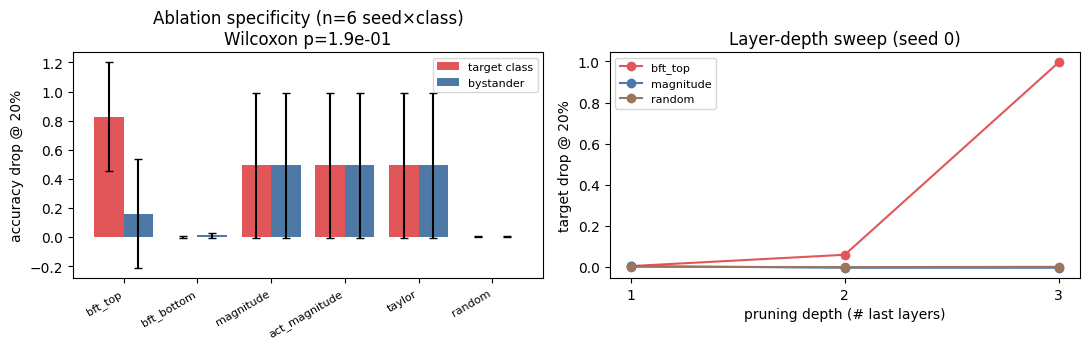

  saved figs/08_validation/fig_ablation_pruning.pdf


'/Users/johannesbertram/repos/Weight_Interpretability/figs/08_validation/fig_ablation_pruning.pdf'

In [9]:
# ── §7 Causal pruning across seeds + significance ───────────────────────────────
print('\n§7 ablation (multi-seed)')
mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
mask = np.isin(np.array(mnist_test_full.targets), DIGIT_FILTER)
test_loader_abl = DataLoader(Subset(mnist_test_full, np.where(mask)[0]),
                             batch_size=256, shuffle=False)
ABL_METHODS = ['bft_top', 'bft_bottom', 'magnitude', 'act_magnitude', 'taylor', 'random']

trees_by_seed_aux = {}
# rows: one per (seed, target_class); columns: per method drop dicts
target_drops = {m: [] for m in ABL_METHODS}     # drop on the target class @0.20
bystd_drops = {m: [] for m in ABL_METHODS}      # drop on the other class  @0.20
auc_drops = {m: [] for m in ABL_METHODS}        # mean target drop over fractions
FRAC_STAT = 0.20
for seed in SEED_SUBSET:
    m_s, cfg_s = models_by_seed[seed]
    coll_s = collect_layer_dicts(m_s, trace_loader, label_transform=label_transform, device=DEVICE)
    li_s = [d['input_fmap'] for d in coll_s['layer_data']]
    tree_s = bft(m_s, val_loader, k_max=K_MAX_PER_LAYER, n_branches=N_BRANCHES,
                 stimulus_threshold=STIMULUS_THRESHOLD, max_iter=AUX_MAX_ITER, n_jobs=3)
    trees_by_seed_aux[seed] = tree_s
    for d in range(N_CLASSES):
        ab = ablation_sweep(m_s, tree_s, test_loader_abl, target_class=d,
                            fractions=ABLATION_FRACS, methods=ABL_METHODS,
                            label_transform=label_transform_even_odd, device=DEVICE,
                            n_random_repeats=5, layer_inputs_list=li_s, verbose=0)
        base = ab.baseline
        other = [c for c in range(N_CLASSES) if c != d]
        for m in ABL_METHODS:
            tdrop = base[d] - ab.results[m][FRAC_STAT][d]
            bdrop = np.mean([base[c] - ab.results[m][FRAC_STAT][c] for c in other])
            target_drops[m].append(tdrop)
            bystd_drops[m].append(bdrop)
            auc_drops[m].append(np.mean([base[d] - ab.results[m][f][d] for f in ABLATION_FRACS]))
    print(f'  seed {seed} done')

# significance: bft_top target vs bystander drop; bft_top vs random target AUC
t_bt = np.array(target_drops['bft_top']); b_bt = np.array(bystd_drops['bft_top'])
w_stat, w_p = wilcoxon(t_bt, b_bt) if len(t_bt) >= 2 and np.any(t_bt != b_bt) else (np.nan, np.nan)
tt_stat, tt_p = ttest_rel(auc_drops['bft_top'], auc_drops['random']) if len(t_bt) >= 2 else (np.nan, np.nan)
results['ablation'] = {
    'frac_stat': FRAC_STAT, 'n_obs': len(t_bt),
    'target_drop': {m: [float(x) for x in target_drops[m]] for m in ABL_METHODS},
    'bystander_drop': {m: [float(x) for x in bystd_drops[m]] for m in ABL_METHODS},
    'target_drop_mean': {m: float(np.mean(target_drops[m])) for m in ABL_METHODS},
    'bystander_drop_mean': {m: float(np.mean(bystd_drops[m])) for m in ABL_METHODS},
    'wilcoxon_bft_top_target_vs_bystander': {'stat': float(w_stat), 'p': float(w_p)},
    'ttest_bft_top_vs_random_targetAUC': {'stat': float(tt_stat), 'p': float(tt_p)},
}
print(f'  bft_top target drop={t_bt.mean():.3f} bystander={b_bt.mean():.3f} '
      f'Wilcoxon p={w_p:.2e}; bft_top vs random AUC t-test p={tt_p:.2e}')

# layer-depth sweep on seed 0 for the depth panel
depth_sweep = ablation_layer_sweep(
    models_by_seed[0][0], trees_by_seed_aux[list(SEED_SUBSET)[0]], test_loader_abl,
    target_class=0, fractions=ABLATION_FRACS,
    methods=['bft_top', 'magnitude', 'random'],
    label_transform=label_transform_even_odd, device=DEVICE, n_random_repeats=5,
    layer_inputs_list=None, verbose=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
x = np.arange(len(ABL_METHODS))
ax[0].bar(x - 0.2, [np.mean(target_drops[m]) for m in ABL_METHODS], 0.4,
          yerr=[np.std(target_drops[m]) for m in ABL_METHODS], capsize=3,
          label='target class', color='#e15759')
ax[0].bar(x + 0.2, [np.mean(bystd_drops[m]) for m in ABL_METHODS], 0.4,
          yerr=[np.std(bystd_drops[m]) for m in ABL_METHODS], capsize=3,
          label='bystander', color='#4e79a7')
ax[0].set_xticks(x); ax[0].set_xticklabels(ABL_METHODS, rotation=30, ha='right', fontsize=8)
ax[0].set(ylabel=f'accuracy drop @ {int(FRAC_STAT*100)}%',
          title=f'Ablation specificity (n={len(t_bt)} seed×class)\nWilcoxon p={w_p:.1e}')
ax[0].legend(fontsize=8)
depths = sorted(depth_sweep)
for m, c in [('bft_top', '#e15759'), ('magnitude', '#4e79a7'), ('random', '#9c755f')]:
    ys = [depth_sweep[dp].baseline[0] - depth_sweep[dp].results[m][FRAC_STAT][0] for dp in depths]
    ax[1].plot(depths, ys, 'o-', c=c, label=m)
ax[1].set(xlabel='pruning depth (# last layers)', ylabel=f'target drop @ {int(FRAC_STAT*100)}%',
          title='Layer-depth sweep (seed 0)'); ax[1].set_xticks(depths); ax[1].legend(fontsize=8)
fig.tight_layout()
savefig(fig, 'fig_ablation_pruning.pdf')

## §8 · Experiment A1 — weight×activation arbor vs activation-only NMF

The CRAFT defense: does the weight term matter? Compares stability, top-factor class selectivity, and fingerprint separability of the W·a arbor vs activation-only NMF.


§8 A1 weight-vs-activation


  causal neuron ablation (mean drop) bft=0.021 act=0.021 random=0.002
  per-layer selectivity (arbor vs act): {0: (0.97, 0.87), 1: (0.97, 0.99), 2: (1.0, 1.0)}
  fp separability arbor knn=1.000 vs act knn=1.000


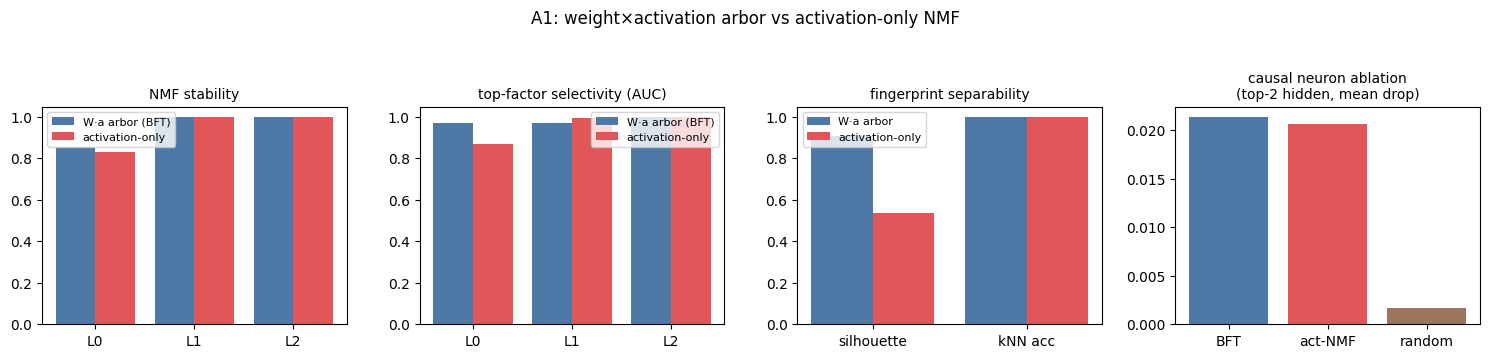

  saved figs/08_validation/fig_a1_weight_vs_activation.pdf


'/Users/johannesbertram/repos/Weight_Interpretability/figs/08_validation/fig_a1_weight_vs_activation.pdf'

In [10]:
# ── §8 A1: weight×activation arbor NMF vs activation-only NMF ────────────────────
print('\n§8 A1 weight-vs-activation')


def fit_nmf(X, k):
    """Fit on a row subsample (speed), transform the full matrix for loadings."""
    Xc = np.clip(X, 0, None).astype(np.float32)
    nmf = MiniBatchNMF(n_components=k, random_state=0, max_iter=AUX_MAX_ITER,
                       batch_size=1024, init='random')
    nmf.fit(sub_rows(Xc))
    return nmf.transform(Xc), nmf.components_.T


def class_selectivity(Wload, y):
    """Bounded selectivity: max over factors of ROC-AUC of the factor loading
    predicting class (folded to [0.5, 1]). 0.5 = no selectivity, 1.0 = perfect."""
    from sklearn.metrics import roc_auc_score
    best = 0.5
    for k in range(Wload.shape[1]):
        col = Wload[:, k]
        if col.std() < 1e-12:
            continue
        auc = roc_auc_score(y, col)
        best = max(best, auc, 1 - auc)
    return float(best)


a1 = {'per_layer': {}}
act_fp_parts, arbor_fp_parts = [], []
for li in layer_ids:
    nd = nodes_by_layer[li]
    k = nd.img_factors.shape[1]
    Xarb = arbor_pos(nd)
    Aact = np.clip(layer_inputs[li], 0, None)
    kA = min(k, Aact.shape[1])
    _, off_arb = stab_mean(Xarb, k)
    _, off_act = stab_mean(Aact, kA)
    Warb, _ = fit_nmf(Xarb, k)
    Wact, _ = fit_nmf(Aact, kA)
    a1['per_layer'][li] = {
        'stability_arbor': float(off_arb.mean()),
        'stability_act': float(off_act.mean()),
        'selectivity_arbor': class_selectivity(Warb, labels),
        'selectivity_act': class_selectivity(Wact, labels),
    }
    arbor_fp_parts.append(Warb)
    act_fp_parts.append(Wact)
arbor_fp = np.concatenate(arbor_fp_parts, axis=1)
act_fp = np.concatenate(act_fp_parts, axis=1)
sil_arb, knn_arb = sep_metrics(arbor_fp, labels)
sil_actfp, knn_actfp = sep_metrics(act_fp, labels)
a1['fingerprint_separability'] = {
    'arbor_nmf': {'silhouette': sil_arb, 'knn_acc': knn_arb},
    'activation_nmf': {'silhouette': sil_actfp, 'knn_acc': knn_actfp},
}

# (d) Causal neuron ablation: does BFT (weight-grounded) neuron importance identify
# more causally-necessary hidden units than activation-only NMF importance?
from sklearn.metrics import roc_auc_score as _auc
base_acc = per_class_accuracy(model, test_loader_abl, label_transform_even_odd, DEVICE)
L_HID = 0                                    # linear layer 0 -> the 8 hidden units
n_hid = LAYER_SIZES[L_HID]
TOPK = max(1, n_hid // 4)
Wact_h, Hact_h = fit_nmf(layer_inputs[L_HID + 1], min(3, n_hid))   # loadings/comp on hidden acts


def _ablate_neuron_drop(neurons, d):
    keys = [(L_HID + 1, o, int(i)) for i in neurons for o in range(LAYER_SIZES[L_HID + 1])]
    abl = ablate_model(model, keys)
    acc = per_class_accuracy(abl, test_loader_abl, label_transform_even_odd, DEVICE)
    return float(base_acc[d] - acc[d])


a1_caus = {'top_k': int(TOPK), 'per_class': {}}
for d in range(N_CLASSES):
    sc, _ = select_class_circuit(tree_root, all_targets, d)
    bft_imp = np.zeros(n_hid)
    for (l, i, j), v in sc.items():
        if l == L_HID:
            bft_imp[i] += abs(v)
    y = (all_targets == d).astype(int)
    aucs = [max(_auc(y, Wact_h[:, k]), 1 - _auc(y, Wact_h[:, k])) for k in range(Wact_h.shape[1])]
    act_imp = Hact_h[:, int(np.argmax(aucs))]
    rng_neurons = RNG.choice(n_hid, TOPK, replace=False)
    a1_caus['per_class'][CLASS_NAMES[d]] = {
        'bft_drop': _ablate_neuron_drop(np.argsort(bft_imp)[::-1][:TOPK], d),
        'act_drop': _ablate_neuron_drop(np.argsort(act_imp)[::-1][:TOPK], d),
        'random_drop': _ablate_neuron_drop(rng_neurons, d),
    }
a1['causal_neuron_ablation'] = a1_caus
results['A1_weight_vs_activation'] = a1
_cm = a1_caus['per_class']
print('  causal neuron ablation (mean drop) bft=%.3f act=%.3f random=%.3f' % (
    np.mean([v['bft_drop'] for v in _cm.values()]),
    np.mean([v['act_drop'] for v in _cm.values()]),
    np.mean([v['random_drop'] for v in _cm.values()])))
print('  per-layer selectivity (arbor vs act):',
      {li: (round(a1['per_layer'][li]['selectivity_arbor'], 2),
            round(a1['per_layer'][li]['selectivity_act'], 2)) for li in layer_ids})
print(f'  fp separability arbor knn={knn_arb:.3f} vs act knn={knn_actfp:.3f}')

fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
xl = np.arange(len(layer_ids))
for a, key, ttl in [(ax[0], 'stability', 'NMF stability'),
                    (ax[1], 'selectivity', 'top-factor selectivity (AUC)')]:
    arb = [a1['per_layer'][li][f'{key}_arbor'] for li in layer_ids]
    act = [a1['per_layer'][li][f'{key}_act'] for li in layer_ids]
    a.bar(xl - 0.2, arb, 0.4, label='W·a arbor (BFT)', color='#4e79a7')
    a.bar(xl + 0.2, act, 0.4, label='activation-only', color='#e15759')
    a.set_xticks(xl); a.set_xticklabels([f'L{li}' for li in layer_ids])
    a.set_title(ttl, fontsize=10); a.legend(fontsize=8)
xb = np.arange(2)
ax[2].bar(xb - 0.2, [sil_arb, knn_arb], 0.4, label='W·a arbor', color='#4e79a7')
ax[2].bar(xb + 0.2, [sil_actfp, knn_actfp], 0.4, label='activation-only', color='#e15759')
ax[2].set_xticks(xb); ax[2].set_xticklabels(['silhouette', 'kNN acc'])
ax[2].set_title('fingerprint separability', fontsize=10); ax[2].legend(fontsize=8)
cm = a1_caus['per_class']
ax[3].bar([0, 1, 2],
          [np.mean([v['bft_drop'] for v in cm.values()]),
           np.mean([v['act_drop'] for v in cm.values()]),
           np.mean([v['random_drop'] for v in cm.values()])],
          color=['#4e79a7', '#e15759', '#9c755f'])
ax[3].set_xticks([0, 1, 2]); ax[3].set_xticklabels(['BFT', 'act-NMF', 'random'])
ax[3].set_title(f'causal neuron ablation\n(top-{TOPK} hidden, mean drop)', fontsize=10)
fig.suptitle('A1: weight×activation arbor vs activation-only NMF', y=1.04)
fig.tight_layout()
savefig(fig, 'fig_a1_weight_vs_activation.pdf')

## §9 · Baseline — pixel attribution (Captum)

BFT per-sample pixel maps vs Integrated Gradients / Saliency / magnitude, scored by class discriminability (kNN accuracy from the per-sample attribution map).


§9 attribution baselines


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  discriminability even/odd: {'BFT': 0.982, 'IG': 0.997, 'Saliency': 0.998, 'magnitude': 0.997}
  discriminability 4-digit : {'BFT': 0.931, 'IG': 0.987, 'Saliency': 0.903, 'magnitude': 0.987}


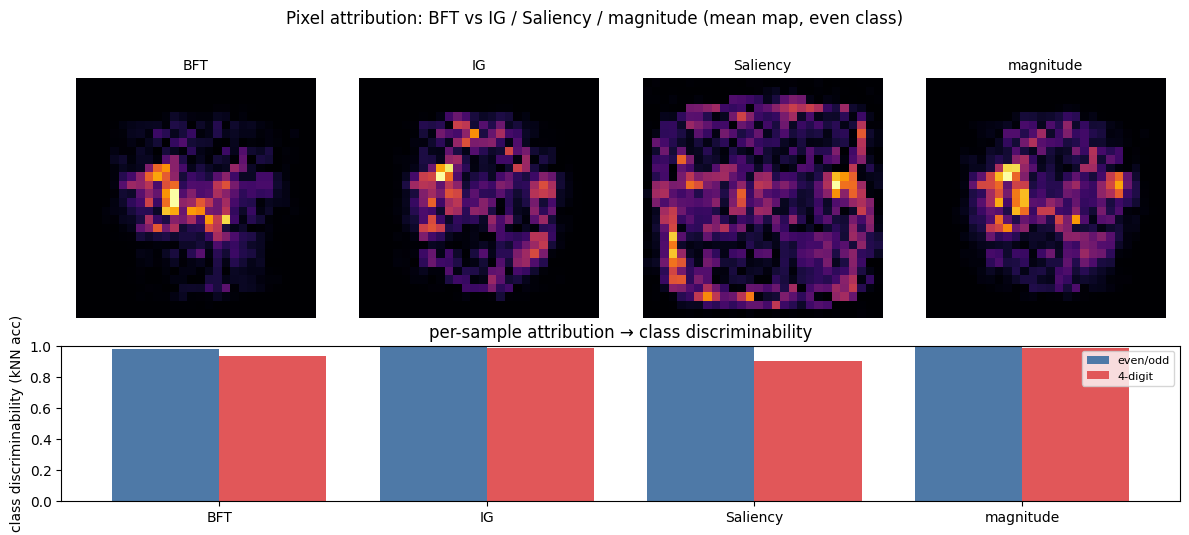

  saved figs/08_validation/fig_attribution_baselines.pdf


'/Users/johannesbertram/repos/Weight_Interpretability/figs/08_validation/fig_attribution_baselines.pdf'

In [11]:
# ── §9 Pixel attribution baselines (Captum) ─────────────────────────────────────
print('\n§9 attribution baselines')
from captum.attr import IntegratedGradients, Saliency


class _Wrap(nn.Module):
    def __init__(self, m):
        super().__init__(); self.m = m

    def forward(self, x):
        return self.m(x)[0]


wrap = _Wrap(model).to(DEVICE).eval()
imgs_t = torch.as_tensor(all_images, dtype=torch.float32, device=DEVICE)
targ_t = torch.as_tensor(all_targets, dtype=torch.long, device=DEVICE)
W0 = model.layers[model.linear_layer_indices()[0]].weight.detach().cpu().numpy()  # (8,784)

# BFT per-sample pixel maps: reconstruct input-layer arbor and sum over output neurons
bft_maps = np.zeros((n_samples, 784))
for nd in tree_root.nodes():
    if nd.layer_idx == li0:
        rec = nd.img_factors @ nd.connection_factors.T          # (N, n_out*n_in)
        n_out = nd.weight.shape[0]
        bft_maps += np.abs(rec.reshape(n_samples, n_out, 784).sum(axis=1))

ig, sal = IntegratedGradients(wrap), Saliency(wrap)
ig_maps = np.zeros((n_samples, 784)); sal_maps = np.zeros((n_samples, 784))
B = 512
for s in range(0, n_samples, B):
    xb = imgs_t[s:s+B].clone().requires_grad_(True)
    yb = targ_t[s:s+B]
    ig_maps[s:s+B] = ig.attribute(xb, target=yb, n_steps=IG_STEPS).abs().reshape(len(yb), -1).detach().cpu().numpy()
    xb2 = imgs_t[s:s+B].clone().requires_grad_(True)
    sal_maps[s:s+B] = sal.attribute(xb2, target=yb).abs().reshape(len(yb), -1).detach().cpu().numpy()
mag_maps = np.abs(flatten_imgs := all_images.reshape(n_samples, -1)) * np.abs(W0).sum(0)[None, :]

attr = {'BFT': bft_maps, 'IG': ig_maps, 'Saliency': sal_maps, 'magnitude': mag_maps}


def discriminability(maps, y):
    Xn = maps / (np.linalg.norm(maps, axis=1, keepdims=True) + 1e-12)
    return float(cross_val_score(KNeighborsClassifier(5), Xn, y, cv=5).mean())


disc = {k: discriminability(v, labels) for k, v in attr.items()}          # even/odd
disc_digit = {k: discriminability(v, all_digits.astype(int)) for k, v in attr.items()}  # 4-digit
results['attribution'] = {
    'class_discriminability_knn_even_odd': disc,
    'class_discriminability_knn_digit': disc_digit,
    'metric': 'kNN(5) 5-fold CV accuracy predicting class from per-sample attribution map'}
print('  discriminability even/odd:', {k: round(v, 3) for k, v in disc.items()})
print('  discriminability 4-digit :', {k: round(v, 3) for k, v in disc_digit.items()})

fig, ax = plt.subplots(2, 4, figsize=(12, 5.2), gridspec_kw={'height_ratios': [2, 1.3]})
even_mask = labels == 0
for j, (k, v) in enumerate(attr.items()):
    ax[0, j].imshow(v[even_mask].mean(0).reshape(28, 28), cmap='inferno')
    ax[0, j].set_title(f'{k}', fontsize=10); ax[0, j].axis('off')
gs = ax[1, 0].get_gridspec()
for a in ax[1, :]:
    a.remove()
axbar = fig.add_subplot(gs[1, :])
mkeys = list(disc); xm = np.arange(len(mkeys))
axbar.bar(xm - 0.2, [disc[k] for k in mkeys], 0.4, label='even/odd', color='#4e79a7')
axbar.bar(xm + 0.2, [disc_digit[k] for k in mkeys], 0.4, label='4-digit', color='#e15759')
axbar.set_xticks(xm); axbar.set_xticklabels(mkeys)
axbar.set(ylabel='class discriminability (kNN acc)', ylim=(0, 1),
          title='per-sample attribution → class discriminability')
axbar.legend(fontsize=8)
fig.suptitle('Pixel attribution: BFT vs IG / Saliency / magnitude (mean map, even class)', y=1.02)
fig.tight_layout()
savefig(fig, 'fig_attribution_baselines.pdf')

## §10 · Validation — cross-seed circuit robustness

Root-factor alignment across independently trained model seeds.


§10 seed robustness
  root factor alignment across seeds: 0.831


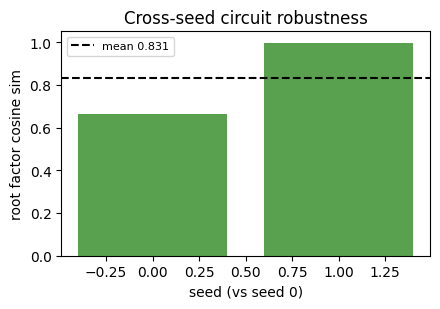

  saved figs/08_validation/fig_seed_robustness.pdf


'/Users/johannesbertram/repos/Weight_Interpretability/figs/08_validation/fig_seed_robustness.pdf'

In [12]:
# ── §10 Model-seed robustness ───────────────────────────────────────────────────
print('\n§10 seed robustness')
seed_factors = []
for seed in SEED_SUBSET:
    H = trees_by_seed_aux[seed].root.img_factors
    seed_factors.append(H / (np.linalg.norm(H, axis=0, keepdims=True) + 1e-12))
_, sim_scores = align_factors(seed_factors[0], seed_factors[1:])
results['seed_robustness'] = {'mean': float(np.mean(sim_scores)) if sim_scores else float('nan'),
                              'std': float(np.std(sim_scores)) if sim_scores else float('nan'),
                              'scores': [float(s) for s in sim_scores]}
print(f'  root factor alignment across seeds: {np.mean(sim_scores):.3f}')
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.bar(range(len(sim_scores)), sim_scores, color='#59a14f')
ax.axhline(np.mean(sim_scores), ls='--', c='k', label=f'mean {np.mean(sim_scores):.3f}')
ax.set(xlabel='seed (vs seed 0)', ylabel='root factor cosine sim', ylim=(0, 1.05),
       title='Cross-seed circuit robustness'); ax.legend(fontsize=8)
fig.tight_layout()
savefig(fig, 'fig_seed_robustness.pdf')

## §12 · Dump all results to JSON

Machine-readable summary of every metric + figure paths → `data/results/nb08_validation.json`.

In [13]:
# ── §12 Dump results JSON ───────────────────────────────────────────────────────
print('\n§12 dump JSON')
results['figures'] = figpaths
results['config'] = {'mode': MODE, 'n_trace': N_TRACE, 'bft_max_iter': BFT_MAX_ITER,
                     'aux_max_iter': AUX_MAX_ITER, 'stab_seeds': STAB_SEEDS,
                     'seed_subset': list(SEED_SUBSET), 'n_samples': n_samples}
out = os.path.join(RES_DIR, 'nb08_validation.json')
with open(out, 'w') as f:
    json.dump(jsonable(results), f, indent=2)
print('  wrote', os.path.relpath(out, REPO))
# round-trip check
with open(out) as f:
    json.load(f)
print('\nALL PHASES OK')


§12 dump JSON
  wrote data/results/nb08_validation.json

ALL PHASES OK
